# Traditional RAG Chunking on a Financial Document

This notebook demonstrates traditional (fixed-size) RAG chunking using LangChain's `RecursiveCharacterTextSplitter` on a single document from the `loong_docs/financial/` corpus.

**Document used:** `2019-avni123118form10k.txt` (Arvana Inc. 10-K, fiscal year 2018)

## 1. Imports & Config

In [3]:
import os
import sys
import textwrap
import matplotlib.pyplot as plt
from langchain_text_splitters import RecursiveCharacterTextSplitter

# Make sure repo root is on the path so we can reuse config.py
REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

# Chunking hyperparameters (mirror config.py defaults)
CHUNK_SIZE    = 300
CHUNK_OVERLAP = 100

DOC_PATH = os.path.join(
    REPO_ROOT, "documents", "loong_docs", "financial",
    "2019-avni123118form10k.txt"
)

print(f"Document path: {DOC_PATH}")
print(f"Chunk size: {CHUNK_SIZE} chars  |  Overlap: {CHUNK_OVERLAP} chars")

Document path: /Users/tejo9855/Documents/Classes/Spring '26/Computational Discourse/ComputationalModelsOfDiscourseRAG/documents/loong_docs/financial/2019-avni123118form10k.txt
Chunk size: 300 chars  |  Overlap: 100 chars


## 2. Load the Document

In [4]:
with open(DOC_PATH, "r", encoding="utf-8") as f:
    raw_text = f.read()

print(f"Document length : {len(raw_text):,} characters")
print(f"Approximate word count: {len(raw_text.split()):,}")
print("\n--- First 500 characters ---")
print(raw_text[:500])

Document length : 122,809 characters
Approximate word count: 14,683

--- First 500 characters ---
﻿10-K 1 avni123118form10k.htm FORM 10-K 
UNITED STATES
SECURITIES AND EXCHANGE COMMISSION
Washington, D.C. 20549 
FORM 10-K
(Mark One)
☒ ANNUAL REPORT PURSUANT TO SECTION 13 OR 15(D) OF THE SECURITIES EXCHANGE ACT OF 1934
For the fiscal year ended December 31, 2018.
☐ TRANSITION REPORT PURSUANT TO SECTION 13 OR 15(D) OF THE SECURITIES EXCHANGE ACT OF 1934
For the transition period from __ to __.
Commission file number: 0-30695
ARVANA INC.
(Exact name of registrant as specified in its charter)
  


## 3. Chunk the Document

`RecursiveCharacterTextSplitter` tries the separators in order (`\n\n`, `\n`, `. `, ` `, `""`) and recurses until every piece is ≤ `CHUNK_SIZE` characters.

In [5]:
splitter = RecursiveCharacterTextSplitter(
    chunk_size=CHUNK_SIZE,
    chunk_overlap=CHUNK_OVERLAP,
    length_function=len,
    separators=["\n\n", "\n", ". ", " ", ""],
    keep_separator=True,
)

chunks = splitter.split_text(raw_text)

print(f"Total chunks produced: {len(chunks)}")
print(f"Avg chunk length     : {sum(len(c) for c in chunks) / len(chunks):.1f} chars")
print(f"Min chunk length     : {min(len(c) for c in chunks)} chars")
print(f"Max chunk length     : {max(len(c) for c in chunks)} chars")

Total chunks produced: 630
Avg chunk length     : 197.0 chars
Min chunk length     : 1 chars
Max chunk length     : 300 chars


## 4. Inspect Sample Chunks

In [6]:
SAMPLE_INDICES = [0, 1, 2, len(chunks) // 2, len(chunks) - 1]

for idx in SAMPLE_INDICES:
    chunk = chunks[idx]
    print(f"{'='*60}")
    print(f" Chunk #{idx}  ({len(chunk)} chars)")
    print(f"{'='*60}")
    print(textwrap.fill(chunk, width=80))
    print()

 Chunk #0  (266 chars)
﻿10-K 1 avni123118form10k.htm FORM 10-K  UNITED STATES SECURITIES AND EXCHANGE
COMMISSION Washington, D.C. 20549  FORM 10-K (Mark One) ☒ ANNUAL REPORT PURSUANT
TO SECTION 13 OR 15(D) OF THE SECURITIES EXCHANGE ACT OF 1934 For the fiscal
year ended December 31, 2018.

 Chunk #1  (275 chars)
For the fiscal year ended December 31, 2018. ☐ TRANSITION REPORT PURSUANT TO
SECTION 13 OR 15(D) OF THE SECURITIES EXCHANGE ACT OF 1934 For the transition
period from __ to __. Commission file number: 0-30695 ARVANA INC. (Exact name of
registrant as specified in its charter)

 Chunk #2  (206 chars)
Commission file number: 0-30695 ARVANA INC. (Exact name of registrant as
specified in its charter)                                Nevada
87-0618509

 Chunk #315  (197 chars)
The Company considers comprehensive income (loss) as a change in equity (net
assets) of a business entity during a period from transactions and other events
and circumstances from non-owner sources

 Chunk #629  

## 5. Visualise Chunk-Length Distribution

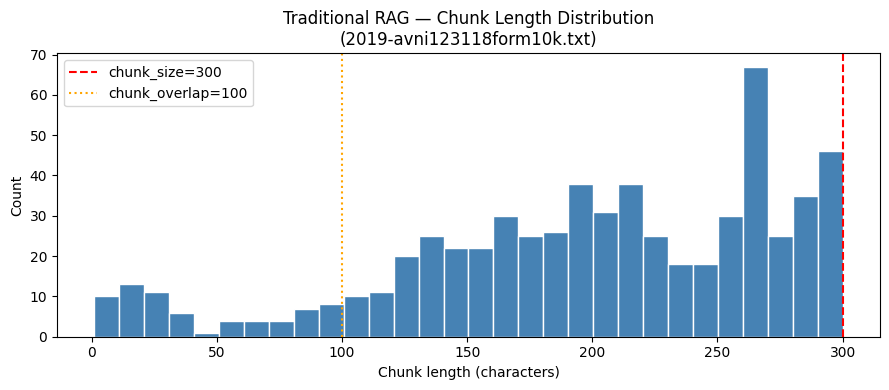

In [7]:
chunk_lengths = [len(c) for c in chunks]

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(chunk_lengths, bins=30, color="steelblue", edgecolor="white")
ax.axvline(CHUNK_SIZE, color="red",    linestyle="--", label=f"chunk_size={CHUNK_SIZE}")
ax.axvline(CHUNK_OVERLAP, color="orange", linestyle=":", label=f"chunk_overlap={CHUNK_OVERLAP}")
ax.set_xlabel("Chunk length (characters)")
ax.set_ylabel("Count")
ax.set_title("Traditional RAG — Chunk Length Distribution\n(2019-avni123118form10k.txt)")
ax.legend()
plt.tight_layout()
plt.show()

## 6. Show Overlap Between Consecutive Chunks

Because `chunk_overlap > 0`, consecutive chunks share a suffix/prefix. This cell checks how much text actually overlaps between chunk *i* and chunk *i+1*.

In [8]:
def measure_overlap(chunk_a: str, chunk_b: str) -> int:
    """Return the length of the longest suffix of chunk_a that is a prefix of chunk_b."""
    max_overlap = min(len(chunk_a), len(chunk_b))
    for size in range(max_overlap, 0, -1):
        if chunk_a[-size:] == chunk_b[:size]:
            return size
    return 0

# Check the first 10 consecutive pairs
print(f"{'Pair':>6}  {'Overlap (chars)':>16}")
print("-" * 28)
for i in range(min(10, len(chunks) - 1)):
    ov = measure_overlap(chunks[i], chunks[i + 1])
    print(f"{i:>3}-{i+1:<3}  {ov:>16}")

  Pair   Overlap (chars)
----------------------------
  0-1                  44
  1-2                  98
  2-3                   0
  3-4                  51
  4-5                   0
  5-6                   0
  6-7                  98
  7-8                   0
  8-9                   0
  9-10                 98


## 7. Build a Chunk DataFrame (Optional, for Further Analysis)

In [9]:
import pandas as pd

df = pd.DataFrame({
    "chunk_id": [f"2019-avni123118form10k.txt_chunk_{i}" for i in range(len(chunks))],
    "chunk_index": range(len(chunks)),
    "text": chunks,
    "length": chunk_lengths,
})

print(f"DataFrame shape: {df.shape}")
df.head(5)

DataFrame shape: (630, 4)


,chunk_id,chunk_index,text,length
0,2019-avni123118form10k.txt_chunk_0,0,﻿10-K 1 avni123118form10k.htm FORM 10-K \nUNIT...,266
1,2019-avni123118form10k.txt_chunk_1,1,"For the fiscal year ended December 31, 2018.\n...",275
2,2019-avni123118form10k.txt_chunk_2,2,Commission file number: 0-30695\nARVANA INC.\n...,206
3,2019-avni123118form10k.txt_chunk_3,3,(State or other jurisdiction of incorporation ...,230
4,2019-avni123118form10k.txt_chunk_4,4,(Address of principal executive offices) (Zip ...,283
